# PyEncode — Explore

Interactive notebook for playing with each PyEncode pattern and composition.

- **One cell per pattern.**  Edit the constructor and `N`, re-run.
- **`validate=True`** is on by default — every cell verifies the prepared
  statevector matches the analytic target up to a global phase.  Disable
  with `validate=False` for large `N`.
- For paper-quality figures, run `generate_figures.py` instead — that
  script is the source of truth for figures referenced in the paper.


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector

from pyencode import (
    encode, predict_gates,
    SPARSE, STEP, SQUARE, FOURIER, WALSH, GEOMETRIC,
    HAMMING, STAIRCASE, DICKE, POLYNOMIAL,
    SUM, PARTITION, TENSOR,
)
from pyencode.mps import encode_mps


def show(circuit, info, N=None, plot=True, scale=0.6):
    """Standard one-stop display: info summary, circuit diagram, prepared vector.

    Parameters
    ----------
    circuit : QuantumCircuit returned by encode() / encode_mps()
    info    : EncodingInfo returned by the same call
    N       : if given, plot the prepared statevector on N basis states.
              For MPS circuits, pass N to project the bond ancillas to |0>.
    plot    : set False to skip the statevector plot
    scale   : circuit-diagram scale factor
    """
    print(info)
    display(circuit.draw('mpl', scale=scale))
    if not plot:
        return
    if N is None:
        return
    sv = Statevector(circuit).data
    n_bond = info.params.get("n_bond", 0) if hasattr(info, "params") else 0
    if n_bond:
        # MPS: data register is qubits [n_bond .. n_bond+m-1]; project bond -> |0>
        m = info.m
        sv = sv.reshape(2 ** m, 2 ** n_bond)[:, 0]
        sv = sv / np.linalg.norm(sv)
    sv = sv[:N]
    fig, ax = plt.subplots(figsize=(5.5, 2.0))
    if np.iscomplexobj(sv) and np.max(np.abs(sv.imag)) > 1e-10:
        ax.bar(np.arange(N) - 0.2, sv.real, width=0.4, label="Re", color="steelblue")
        ax.bar(np.arange(N) + 0.2, sv.imag, width=0.4, label="Im", color="indianred")
        ax.legend(loc="best", fontsize=8)
    else:
        ax.bar(range(N), sv.real, color="steelblue")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_xlabel("index $i$"); ax.set_ylabel(r"$f_i$")
    ax.set_title("Prepared statevector", fontsize=10)
    plt.tight_layout(); plt.show()


## Patterns

### SPARSE — $s$-sparse superposition, $\mathcal{O}(sm)$

$|\psi\rangle \propto \sum_j \alpha_j |x_j\rangle$

PyEncode  v3.0.0
  Pattern     : SPARSE
  N           : 64  (m = 6 qubits)
  Gate count  : 3
  Complexity  : O(s·m)
  Validated   : yes
  Gates 1q/2q : 3 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (64,)
  Parameters  : {'loads': [{'k': 19, 'P': 1.0}]}
  Circuit code: 272 chars (info.circuit_code)


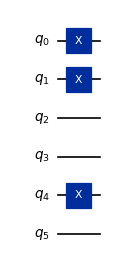

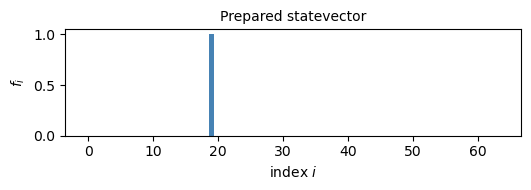

In [2]:
# Try also: SPARSE([(1, 3.0), (6, -4.0)])           # signed real
#           SPARSE([(2, 1+1j), (5, 1-1j)])           # complex
N = 64
pat = SPARSE([(19, 1.0)])

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### STEP — uniform superposition on $[0, k_e)$, $\mathcal{O}(m)$

$f_i = c\,\mathbf{1}[i < k_e]$

PyEncode  v3.0.0
  Pattern     : STEP
  N           : 8  (m = 3 qubits)
  Gate count  : 2
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 2 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (8,)
  Parameters  : {'k_e': 4, 'c': 1.0}
  Circuit code: 370 chars (info.circuit_code)


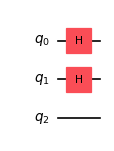

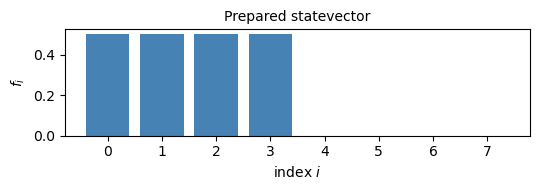

In [3]:
# Try also: STEP(k_e=N, c=1.0)   # full uniform — H^{\otimes m}
N = 8
pat = STEP(k_e=4, c=1.0)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### SQUARE — uniform on a general interval $[k_s, k_e)$, $\mathcal{O}(m^2)$ (or $\mathcal{O}(m)$ if aligned)

$f_i = c\,\mathbf{1}[k_s \le i < k_e]$

PyEncode  v3.0.0
  Pattern     : SQUARE
  N           : 8  (m = 3 qubits)
  Gate count  : 7
  Complexity  : O(m²)
  Validated   : yes
  Gates 1q/2q : 5 / 1
  Depth       : 3
  Success prob: 1.0
  Vector      : numpy array, shape (8,)
  Parameters  : {'k_s': 2, 'k_e': 6, 'c': 1.0}
  Circuit code: 1916 chars (info.circuit_code)


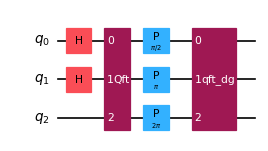

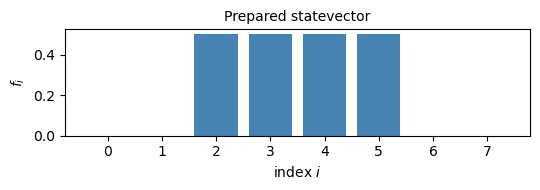

In [4]:
# Power-of-2-aligned (e.g. k_s=0 or k_s=N/2) drops to O(m).
N = 8
pat = SQUARE(k_s=2, k_e=6, c=1.0)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### FOURIER — superposition of sinusoidal modes, $\mathcal{O}(m^2)$

$f_i = \sum_t A_t \sin(2\pi n_t i/N + \varphi_t)$

PyEncode  v3.0.0
  Pattern     : FOURIER
  N           : 16  (m = 4 qubits)
  Gate count  : 9
  Complexity  : O(m²)
  Validated   : yes
  Gates 1q/2q : 20 / 13
  Depth       : 23
  Success prob: 1.0
  Vector      : numpy array, shape (16,)
  Parameters  : {'modes': [{'n': 1, 'A': 1.0, 'phi': 0.0}]}
  Circuit code: 1814 chars (info.circuit_code)


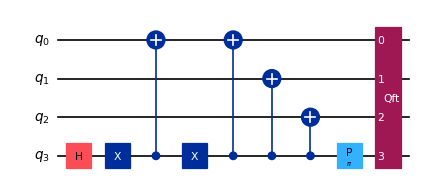

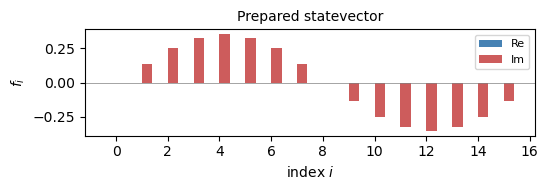

In [5]:
# Try also: FOURIER(modes=[(1, 1.0, 0), (3, 0.5, np.pi/4)])   # multi-mode
N = 16
pat = FOURIER(modes=[(1, 1.0, 0)])

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### WALSH — two-level state on bit-$k$, $\mathcal{O}(m)$

$f_i = c_0$ if bit $k$ of $i$ is $0$, else $c_1$.

PyEncode  v3.0.0
  Pattern     : WALSH
  N           : 8  (m = 3 qubits)
  Gate count  : 4
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 3 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (8,)
  Parameters  : {'k': 2, 'c0': 1.0, 'c1': 4.0}
  Circuit code: 315 chars (info.circuit_code)


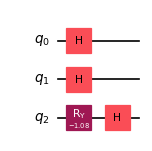

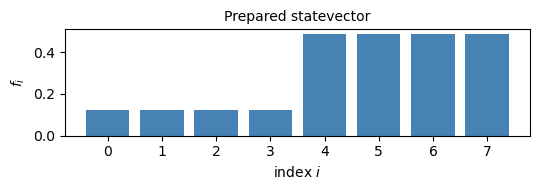

In [6]:
# Try also: WALSH(k=0, c0=1.0, c1=-1.0)   # signed uniform (standard Walsh)
N = 8
pat = WALSH(k=2, c0=1.0, c1=4.0)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### GEOMETRIC — $f_i = c\,r^{i-k_s}$ on $[k_s, N)$, $\mathcal{O}(m)$ for $k_s=0$, $\mathcal{O}(m^2)$ otherwise

`k_s=0` gives a depth-1 product state with zero entangling gates.

PyEncode  v3.0.0
  Pattern     : GEOMETRIC
  N           : 8  (m = 3 qubits)
  Gate count  : 3
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 3 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (8,)
  Parameters  : {'r': 0.5, 'k_s': 0, 'k_e': 8, 'c': 1.0}
  Circuit code: 377 chars (info.circuit_code)


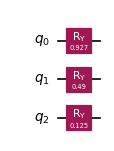

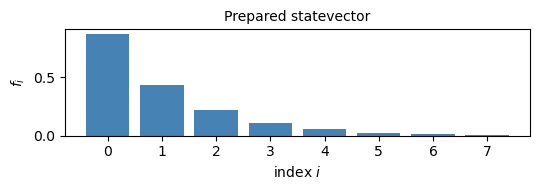

In [7]:
# Try also: GEOMETRIC(r=np.exp(0.7j))           # complex r: discrete plane wave
#           GEOMETRIC(r=0.8, k_s=5)              # offset: dyadic decomposition
N = 8
pat = GEOMETRIC(r=0.5)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### HAMMING — $f_i = c\,r^{\mathrm{wt}(i)}$, $\mathcal{O}(m)$, depth 1

Constant-ratio specialization of GEOMETRIC across qubits.

PyEncode  v3.0.0
  Pattern     : HAMMING
  N           : 16  (m = 4 qubits)
  Gate count  : 4
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 4 / 0
  Depth       : 1
  Success prob: 1.0
  Vector      : numpy array, shape (16,)
  Parameters  : {'r': 0.5, 'c': 1.0}
  Circuit code: 436 chars (info.circuit_code)


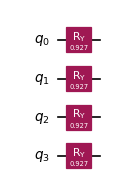

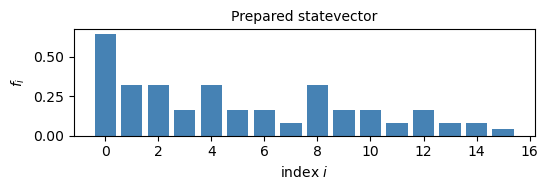

In [8]:
N = 16
pat = HAMMING(r=0.5)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### STAIRCASE — $f_{2^k - 1} = c\,r^k$ on unary indices, $\mathcal{O}(m)$

Sparse geometric on $\{0, 1, 3, 7, 15, \ldots\}$.

PyEncode  v3.0.0
  Pattern     : STAIRCASE
  N           : 16  (m = 4 qubits)
  Gate count  : 4
  Complexity  : O(m)
  Validated   : yes
  Gates 1q/2q : 7 / 6
  Depth       : 10
  Success prob: 1.0
  Vector      : numpy array, shape (16,)
  Parameters  : {'r': 0.5, 'c': 1.0}
  Circuit code: 651 chars (info.circuit_code)


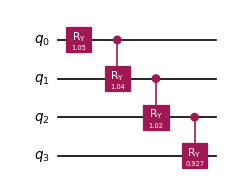

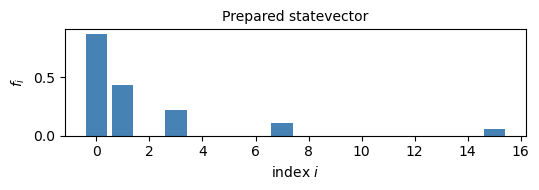

In [9]:
N = 16
pat = STAIRCASE(r=0.5)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### DICKE — uniform over weight-$k$ basis states, $\mathcal{O}(k(m-k))$

$|D^m_k\rangle$ — genuinely entangled, not a product state.

PyEncode  v3.0.0
  Pattern     : DICKE
  N           : 16  (m = 4 qubits)
  Gate count  : 17
  Complexity  : O(k*(m-k))
  Validated   : yes
  Gates 1q/2q : 34 / 24
  Depth       : 41
  Success prob: 1.0
  Vector      : numpy array, shape (16,)
  Parameters  : {'k': 2, 'c': 1.0}
  Circuit code: 2545 chars (info.circuit_code)


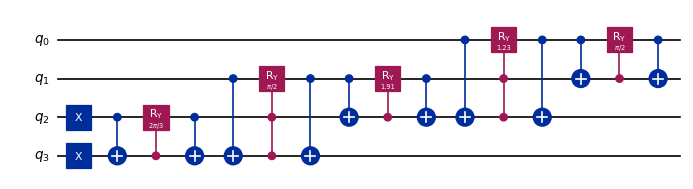

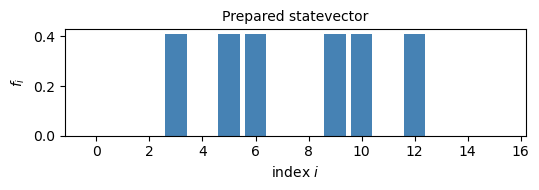

In [10]:
# Try also: DICKE(k=11) on N=16 — uses k > m/2 symmetry path
N = 16
pat = DICKE(k=2)

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


### POLYNOMIAL — $f_i = \sum_j c_j (i/(N{-}1))^j$, $\mathcal{O}(m^{d+1})$

Walsh-sparse loading: degree-$d$ polynomial has $\mathcal{O}(m^d)$ Walsh coefficients.

PyEncode  v3.0.0
  Pattern     : POLYNOMIAL
  N           : 64  (m = 6 qubits)
  Gate count  : 17
  Complexity  : O(m^(d+1))
  Validated   : yes
  Gates 1q/2q : 26 / 10
  Depth       : 21
  Success prob: 1.0
  Vector      : numpy array, shape (64,)
  Parameters  : {'coeffs': [0.0, 1.0], 'normalize_domain': True}
  Circuit code: 1188 chars (info.circuit_code)


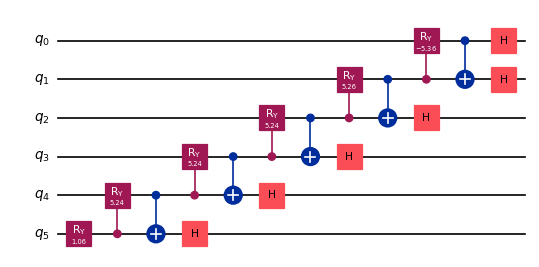

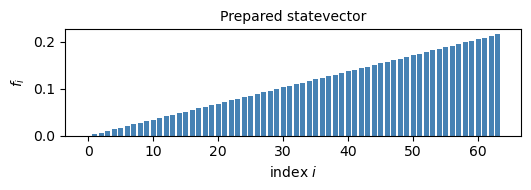

In [11]:
# Try also: POLYNOMIAL(coeffs=[0.0, 4.0, -4.0])   # Poiseuille parabola
#           POLYNOMIAL(coeffs=[0.1, 0.5, 1.0, -0.3]) # cubic
N = 64
pat = POLYNOMIAL(coeffs=[0.0, 1.0])   # ramp f(x) = x

circuit, info = encode(pat, N=N, validate=True)
show(circuit, info, N=N)


## Compositions

### SUM — $\sum_j w_j |f^{(j)}\rangle$, weighted superposition via LCU

Uses bond ancillas + post-selection.  `info.success_probability` gives the success rate.
Disjoint-support components yield $p=1/r$ for $r$ equal-weight components.
**Tip:** if components are disjoint, `PARTITION` is strictly cheaper.

success_probability = 0.6250
PyEncode  v3.0.0
  Pattern     : SUM
  N           : 16  (m = 4 qubits)
  Gate count  : 47
  Complexity  : O(2·m)
  Validated   : yes
  Success prob: 0.6250  (post-selection required)
  Vector      : numpy array, shape (16,)
  Parameters  : {'components': ['SQUARE', 'SQUARE'], 'weights': [1.0, 3.0], 'disjoint': True}
  Circuit code: 2414 chars (info.circuit_code)


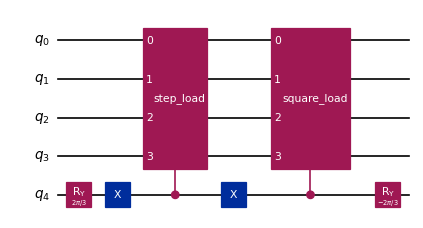

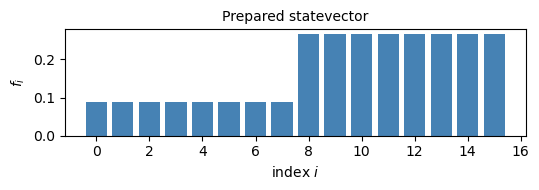

In [12]:
# Try also: overlapping components — emits UserWarning, p < 1
N = 16
pat = SUM([
    (1.0, SQUARE(k_s=0, k_e=8,  c=1.0)),
    (3.0, SQUARE(k_s=8, k_e=16, c=1.0)),
])

circuit, info = encode(pat, N=N, validate=True)
print(f"success_probability = {info.success_probability:.4f}")
show(circuit, info, N=N)


### PARTITION — disjoint-support composition, ancilla-free, $p=1$

Each component must have bounded, pairwise-disjoint support.
Cheaper than SUM whenever disjointness is guaranteed.

success_probability = 1.0
gate_count = 715
PyEncode  v3.0.0
  Pattern     : PARTITION
  N           : 256  (m = 8 qubits)
  Gate count  : 715
  Complexity  : O(L·m)
  Validated   : yes
  Gates 1q/2q : 371 / 397
  Depth       : 478
  Success prob: 1.0
  Vector      : numpy array, shape (256,)
  Parameters  : {'K': 2, 'L': 9, 'components': ['SPARSE', 'GEOMETRIC']}
  Circuit code: 457 chars (info.circuit_code)


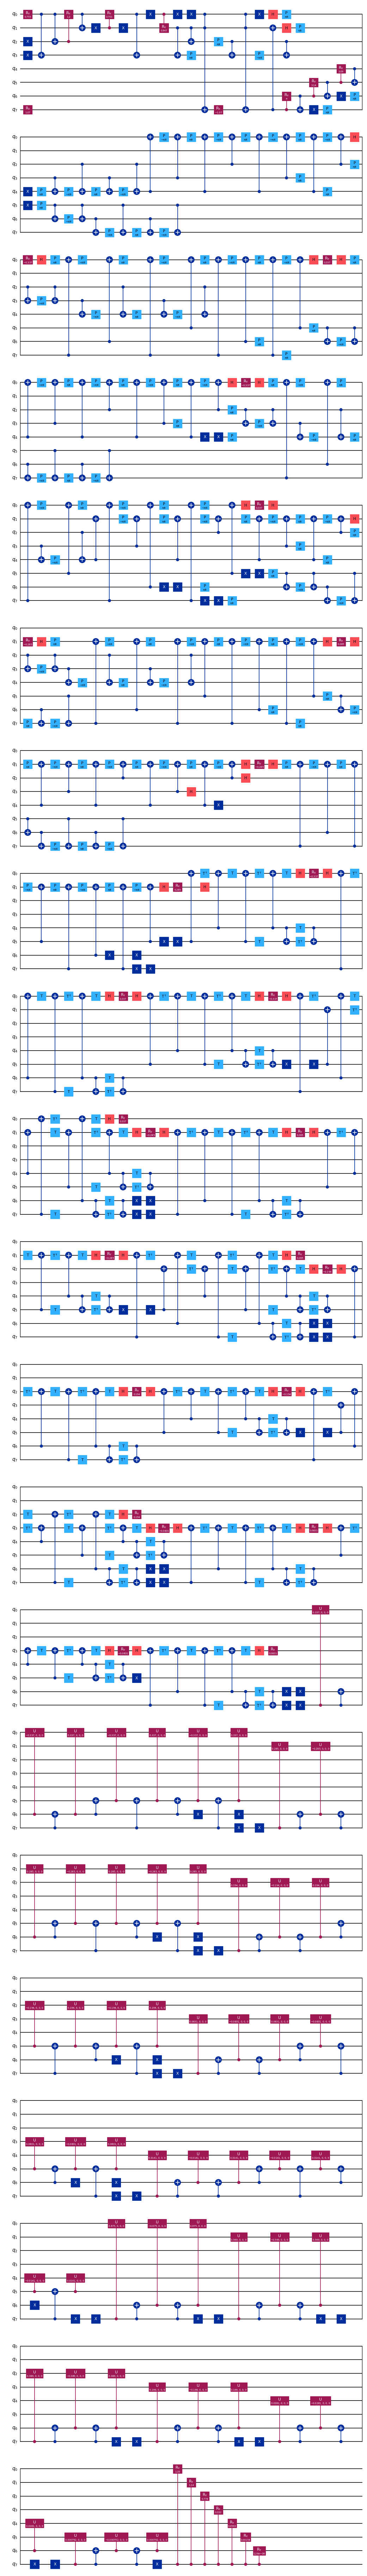

In [13]:
# Components must have disjoint support; otherwise raises ValueError.
N = 256
pat = PARTITION([
    SPARSE([(2, 0.3), (5, 0.5), (7, 0.7)]),
    GEOMETRIC(r=0.8, k_s=11),
])

circuit, info = encode(pat, N=N, validate=True)
print(f"success_probability = {info.success_probability}")
print(f"gate_count = {info.gate_count}")
show(circuit, info, N=N, plot=False)   # N=256 too wide to plot usefully


### TENSOR — separable state $\bigotimes_j |f^{(j)}\rangle$ on disjoint subregisters

Total cost = sum of component costs; depth = max of component depths (parallel).

PyEncode  v3.0.0
  Pattern     : TENSOR
  N           : 1024  (m = 10 qubits)
  Gate count  : 21
  Complexity  : O(sum of components)
  Validated   : yes
  Gates 1q/2q : 62 / 45
  Depth       : 35
  Success prob: 1.0
  Vector      : numpy array, shape (1024,)
  Parameters  : {'K': 2, 'sizes': [32, 32], 'components': ['FOURIER', 'FOURIER']}
  Circuit code: 487 chars (info.circuit_code)


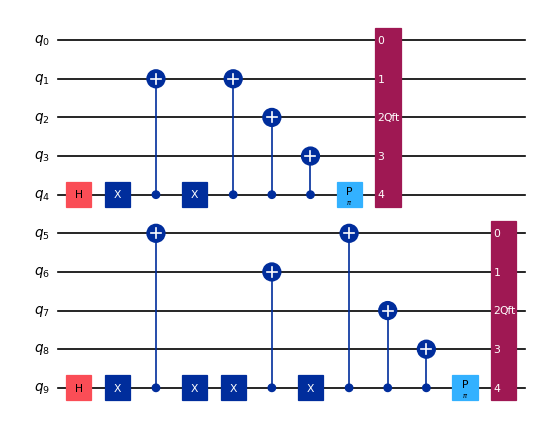

In [14]:
# Separable 2D source: sin(2 pi n_x i/N) * sin(2 pi n_y j/N)
N1 = 32
pat = TENSOR([
    (FOURIER(modes=[(2, 1.0, 0)]), N1),
    (FOURIER(modes=[(3, 1.0, 0)]), N1),
])

circuit, info = encode(pat, N=N1*N1, validate=True)
show(circuit, info, N=None, plot=False)   # 1024-d state — skip the bar plot


## Approximate encoding (MPS)

For amplitude vectors that don't fit any exact pattern.  Operates on a
classical numerical vector at $\mathcal{O}(N)$ classical cost; bond
dimension $\chi$ trades approximation error against gate count.
`info.params["truncation_error_sq"]` upper-bounds $1 - F$.

### encode_mps — Schön sequential cascade, $\mathcal{O}(m\chi^2)$

Bond ancillas return to $|0\rangle$ deterministically — no post-selection.

Transpiling MPS circuit for gate counts...
Transpiled gate counts: 1132 1q gates, 680 2q gates; depth 1339.
truncation_error_sq = 7.61e-21
PyEncode  v3.0.0
  Pattern     : MPS
  N           : 256  (m = 8 qubits)
  Gate count  : 8
  Complexity  : O(m*chi^2) with chi=8
  Validated   : yes
  Gates 1q/2q : 1132 / 680
  Depth       : 1339
  Success prob: 1.0
  Vector      : numpy array, shape (256,)
  Parameters  : {'bond_dim': 8, 'n_bond': 3, 'truncation_error_sq': 7.61400341464205e-21, 'n_padded': 256}


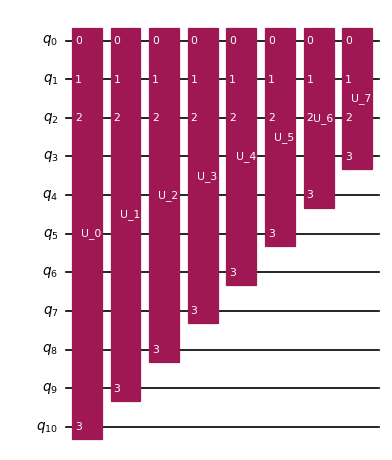

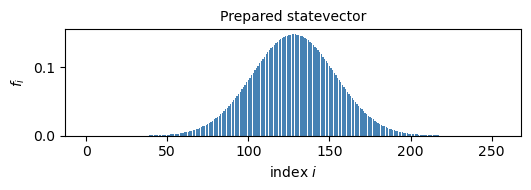

In [15]:
# Try also: vary alpha (Gaussian width), bond_dim (chi), m (problem size).
#           Smaller chi -> larger truncation_error_sq.
m = 8
N = 2 ** m
i = np.arange(N)
alpha = 50.0
v = np.exp(-alpha * ((i - N/2) / N) ** 2)
v /= np.linalg.norm(v)

circuit, info = encode_mps(v, bond_dim=8, validate=True)
print(f"truncation_error_sq = {info.params['truncation_error_sq']:.2e}")
show(circuit, info, N=N)


## Cost prediction without synthesis

`predict_gates` returns transpiled gate counts in closed form, without
constructing the circuit.  Useful for design-space sweeps.

In [16]:
for pat in [
    SPARSE([(19, 1.0)]),
    STEP(k_e=4, c=1.0),
    GEOMETRIC(r=0.95),
    POLYNOMIAL(coeffs=[0.0, 1.0]),
    FOURIER(modes=[(1, 1.0, 0)]),
]:
    p = predict_gates(pat, N=4096)
    print(f"{p['pattern_name']:<12} 1q={p['gate_count_1q']:>4}  "
          f"2q={p['gate_count_2q']:>4}  depth={p['circuit_depth']:>4}  "
          f"{p['complexity']}  exact={p['exact']}")


SPARSE       1q=   3  2q=   0  depth=   1  O(sm)  exact=True
STEP         1q=  11  2q=   0  depth=   1  O(m)  exact=True
GEOMETRIC    1q=  12  2q=   0  depth=   1  O(m)  exact=False
POLYNOMIAL   1q=  56  2q=  22  depth=  45  O(m)  exact=True
FOURIER      1q= 192  2q= 141  depth=  95  O(m^2)  exact=True
